In [141]:
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [142]:
df = pd.read_csv('placement.csv')
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


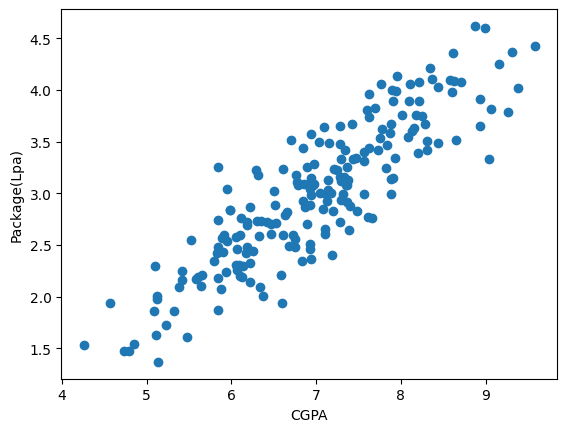

In [143]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel('CGPA')
plt.ylabel('Package(Lpa)')
plt.show()

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cgpa     200 non-null    float64
 1   package  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [145]:
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


In [146]:
# Seperating X & y
X, y = df.iloc[:, 0:1], df.iloc[:,-1]
print(X.shape)
print(y.shape)

(200, 1)
(200,)


In [147]:
# Split the data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(160, 1)
(40, 1)
(160,)
(40,)


In [148]:
lr_reg = LinearRegression() # model object
lr_reg.fit(X_train, y_train) # model training
y_pred = lr_reg.predict(X_test)

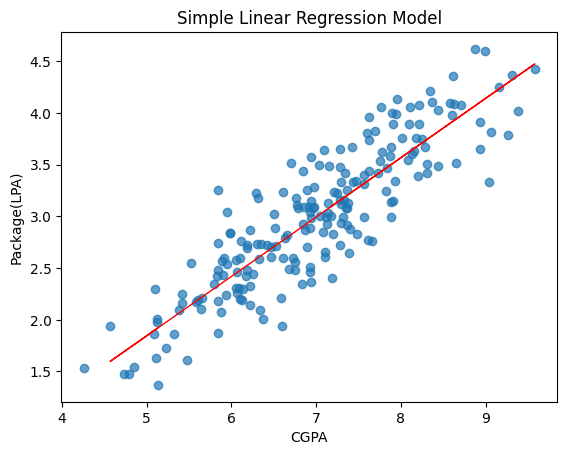

In [149]:
plt.scatter(df['cgpa'],df['package'], alpha=0.7)
plt.plot(X_train, lr_reg.predict(X_train), color='red', linewidth=1)
plt.title('Simple Linear Regression Model')
plt.xlabel('CGPA')
plt.ylabel('Package(LPA)')
plt.show()

In [150]:
print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
print(f'MSE: {mean_squared_error(y_test, y_pred)}')
print(f'RMSE: {np.sqrt(mean_absolute_error(y_test, y_pred))}')

MAE: 0.23150985393278373
MSE: 0.08417638361329657
RMSE: 0.48115470893755546


In [151]:
r2 = r2_score(y_test, y_pred)
samples, features = X_test.shape[0], X_test.shape[1]
adjusted_R2_score = 1 - ((1-r2)*(samples-1))/(samples-1-features)

In [152]:
print(f'R2-score: {r2_score(y_test, y_pred)}')
print(f'Adjusted R2-score: {adjusted_R2_score}')

R2-score: 0.7730984312051673
Adjusted R2-score: 0.7671273372895138


### Experimentation 1 - Adding an Irrelevant column to the dataset

In [153]:
# Adding a new Irrelevant column 
new_df = df.copy()
new_df['Irrelevant_feature'] = np.random.random(200)
new_df = new_df[['cgpa', 'Irrelevant_feature', 'package']] # ordering the columns
new_df.head()

,cgpa,Irrelevant_feature,package
0,6.89,0.282288,3.26
1,5.12,0.333228,1.98
2,7.82,0.763396,3.25
3,7.42,0.758367,3.67
4,6.94,0.731650,3.57


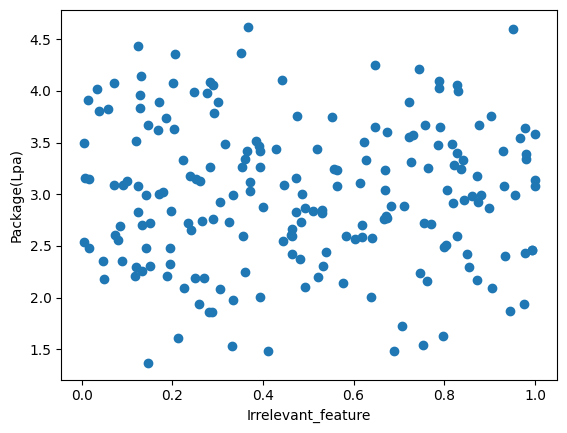

In [154]:
plt.scatter(new_df['Irrelevant_feature'], new_df['package'])
plt.xlabel('Irrelevant_feature')
plt.ylabel('Package(Lpa)')
plt.show()

In [155]:
X_new, y_new = new_df.iloc[:, 0:2], new_df.iloc[:,-1]

In [156]:
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

In [157]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_new, y_train_new)
y_pred_new = lr_reg.predict(X_test_new)

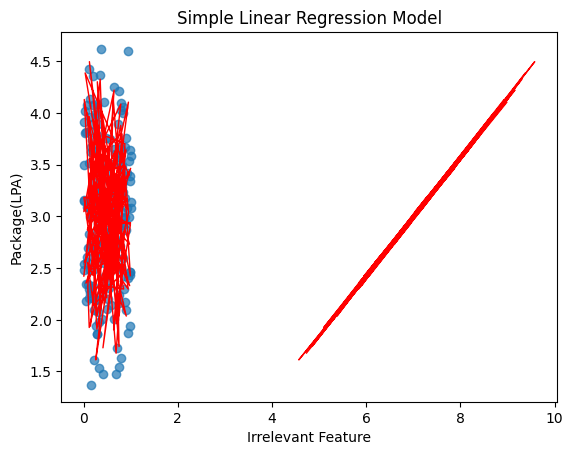

In [158]:
plt.scatter(new_df['Irrelevant_feature'],new_df['package'], alpha=0.7)
plt.plot(X_train_new, lr_reg.predict(X_train_new), color='red', linewidth=1)
plt.title('Simple Linear Regression Model')
plt.xlabel('Irrelevant Feature')
plt.ylabel('Package(LPA)')
plt.show()

In [159]:
print(f'MAE: {mean_absolute_error(y_test_new, y_pred_new)}')
print(f'MSE: {mean_squared_error(y_test_new, y_pred_new)}')
print(f'RMSE: {np.sqrt(mean_absolute_error(y_test_new, y_pred_new))}')

MAE: 0.2323634695606786
MSE: 0.08583755072426939
RMSE: 0.48204094178884704


In [160]:
r2_new = r2_score(y_test_new, y_pred_new)
samples_new, features_new = X_test_new.shape[0], X_test_new.shape[1]
adjusted_R2_score = 1 - ((1-r2_new)*(samples-1))/(samples-1-features)

In [161]:
print(f'R2-score: {r2_score(y_test_new, y_pred_new)}')
print(f'Adjusted R2-score: {adjusted_R2_score}')

R2-score: 0.7686206738184675
Adjusted R2-score: 0.7625317441821114


### Experimentaion 2 - Adding an Relevant Column(IQ) to the dataset

In [162]:
# Adding a new Relevant column 
new_df1 = df.copy()
new_df1['IQ'] = df['package'] + (np.random.randint(-12, 12, 200)/10)
new_df1 = new_df1[['cgpa', 'IQ', 'package']] # ordering the columns
new_df1.head()

,cgpa,IQ,package
0,6.89,3.96,3.26
1,5.12,2.28,1.98
2,7.82,2.95,3.25
3,7.42,2.67,3.67
4,6.94,4.47,3.57


In [163]:
X_new1, y_new1 = new_df1.iloc[:, 0:2], new_df1.iloc[:,-1]

In [164]:
X_train_new1, X_test_new1, y_train_new1, y_test_new1 = train_test_split(X_new1, y_new1, test_size=0.2, random_state=42)

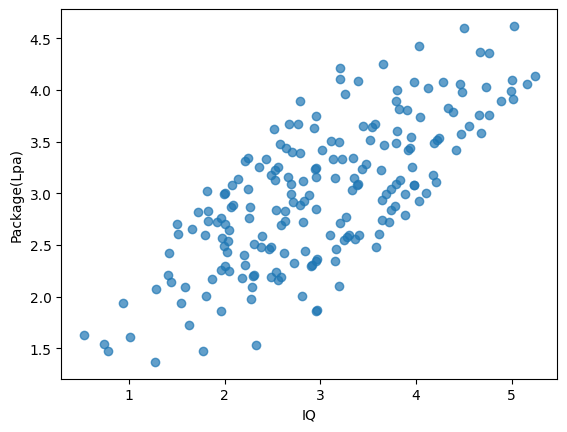

In [165]:
plt.scatter(new_df1['IQ'], new_df1['package'], alpha=0.7)
plt.xlabel('IQ')
plt.ylabel('Package(Lpa)')
plt.show()

In [166]:
lr_reg = LinearRegression()
lr_reg.fit(X_train_new1, y_train_new1)
y_pred_new1 = lr_reg.predict(X_test_new1)

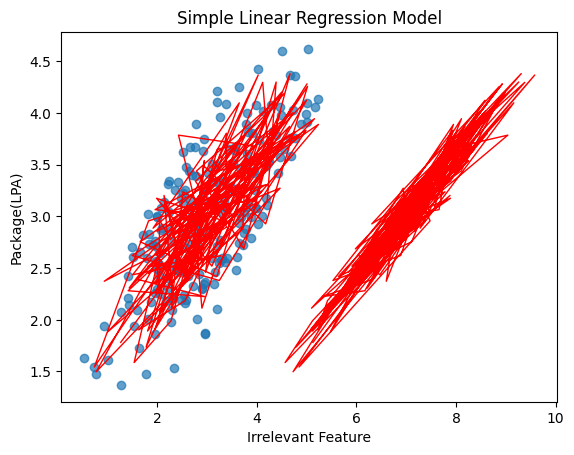

In [167]:
plt.scatter(new_df1['IQ'],new_df1['package'], alpha=0.7)
plt.plot(X_train_new1, lr_reg.predict(X_train_new1), color='red', linewidth=1)
plt.title('Simple Linear Regression Model')
plt.xlabel('Irrelevant Feature')
plt.ylabel('Package(LPA)')
plt.show()

In [168]:
print(f'MAE: {mean_absolute_error(y_test_new1, y_pred_new1)}')
print(f'MSE: {mean_squared_error(y_test_new1, y_pred_new1)}')
print(f'RMSE: {np.sqrt(mean_absolute_error(y_test_new1, y_pred_new1))}')

MAE: 0.22115157173387817
MSE: 0.07637751612509311
RMSE: 0.47026755335008835


In [169]:
r2 = r2_score(y_test_new1, y_pred_new1)
samples, features = X_test_new1.shape[0], X_test_new1.shape[1]
adjusted_R2_score = 1 - ((1-r2)*(samples-1))/(samples-1-features)

In [170]:
print(f'R2-score: {r2_score(y_test_new1, y_pred_new1)}')
print(f'Adjusted R2-score: {adjusted_R2_score}')

R2-score: 0.7941206608607646
Adjusted R2-score: 0.7829920479343195
